## Imported from Daniel

In [1]:
import os
import pandas as pd
from src.data import load_data

df_body, df_title, df_subreddits, df_english_pl, df_esports, df_superbowl, df_holidays = load_data()

THEMES = {
    'sports': [
        'nba', 'nfl', 'hockey', 'fantasyfootball', 'cfb', 'maddenultimateteam', 'baseball', 'golf', 'patriots', 'collegebasketball', 'seahawks', 'minnesotavikings', 'madden', 'greenbaypackers', 'warriors', 'eagles', 'denverbroncos', 'torontobluejays', '49ers', 'lakers', 'browns', 'oaklandraiders'
    ],
    'politics': [
        'the_donald', 'politic', 'conspiracy', 'conservative', 'worldpolitics', 'libertarian', 'mensrights', 'new_right', 'theredpill', 'anarcho_capitalism', 'whiterights', 'european', 'politicalvideo', 'metacanada', 'hillaryforprison', 'uncensorednews', 'asktrumpsupporters', 'altnewz', 'kossacks_for_sanders', 'wayofthebern', 'republican', 'conservatives'
    ],
    'gaming' : [
        'gaming', 'pcmasterrace', 'ps4', 'xboxone', 'games', 'rainbow6', 'minecraft', 'fo4', 'darksouls3', 'thedivision', 'fallout', 'dayz', 'halo', 'darksouls2', 'skyrim', 'grandtheftautov', 'oculus', 'witcher', 'kerbalspaceprogram', 'battlefield_one', 'battlefield_4', 'globaloffensivetrade', 'fireteams', 'rocketleagueexchange', 'dota2', 'leagueoflegends', 'globaloffensive', 'destinythegame', 'overwatch', 'hearthstone', 'wow', '2007scape', 'pokemongo', 'smite', 'runescape'
    ]
}

# Dictionary to hold merged dataframes
merged_dfs = {}

# Merge with the neighbors found (centroid)
for theme_name, initial_subs in THEMES.items():
    neighbors_centroid_path = f'../data/{theme_name}_centroid_neighbors.csv'

    if os.path.exists(neighbors_centroid_path):
        neighbors_df = pd.read_csv(neighbors_centroid_path)

        # Put all names in a list to filter duplicates
        merged_list = list(set(initial_subs + neighbors_df['SUBREDDIT'].tolist()))

        # Get the corresponding embeddings
        merged_df = df_subreddits[df_subreddits['SUBREDDIT'].isin(merged_list)].copy()

        # Save in dictionary for later use
        merged_dfs[f'{theme_name}_centroid'] = merged_df
    else:
        print(f'File not found :( ')

    # Do the same for max similarity neighbors

    neighbors_maxsim_path = f'../data/{theme_name}_max_similarity_neighbors.csv'

    if os.path.exists(neighbors_maxsim_path):
        neighbors_df = pd.read_csv(neighbors_maxsim_path)

        # Put all names in a list to filter duplicates
        merged_list = list(set(initial_subs + neighbors_df['SUBREDDIT'].tolist()))

        # Get the corresponding embeddings
        merged_df = df_subreddits[df_subreddits['SUBREDDIT'].isin(merged_list)].copy()

        # Save in dictionary for later use
        merged_dfs[f'{theme_name}_maxsim'] = merged_df
    else:
        print(f'File not found :( ')

# Dataframes
sports_centroid_df = merged_dfs.get('sports_centroid')
politics_centroid_df = merged_dfs.get('politics_centroid')
gaming_centroid_df = merged_dfs.get('gaming_centroid')
sports_maxsim_df = merged_dfs.get('sports_maxsim')
politics_maxsim_df = merged_dfs.get('politics_maxsim')
gaming_maxsim_df = merged_dfs.get('gaming_maxsim')



## Politics EDA

In [2]:
df_selected = df_body
df_selected.head(5)

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES
0,leagueoflegends,teamredditteams,1u4nrps,2013-12-31 16:39:58,1,"345.0,298.0,0.75652173913,0.0173913043478,0.08..."
1,theredlion,soccer,1u4qkd,2013-12-31 18:18:37,-1,"101.0,98.0,0.742574257426,0.019801980198,0.049..."
2,inlandempire,bikela,1u4qlzs,2014-01-01 14:54:35,1,"85.0,85.0,0.752941176471,0.0235294117647,0.082..."
3,nfl,cfb,1u4sjvs,2013-12-31 17:37:55,1,"1124.0,949.0,0.772241992883,0.0017793594306,0...."
4,playmygame,gamedev,1u4w5ss,2014-01-01 02:51:13,1,"715.0,622.0,0.777622377622,0.00699300699301,0...."


In [14]:
politics_maxsim_df['SUBREDDIT'] = politics_maxsim_df['SUBREDDIT'].astype(str)
df_selected['SOURCE_SUBREDDIT'] = df_selected['SOURCE_SUBREDDIT'].astype(str)


ids_to_keep = politics_maxsim_df['SUBREDDIT'].unique()
df_filtre = df_selected[df_selected['SOURCE_SUBREDDIT'].isin(ids_to_keep)].copy()

Title


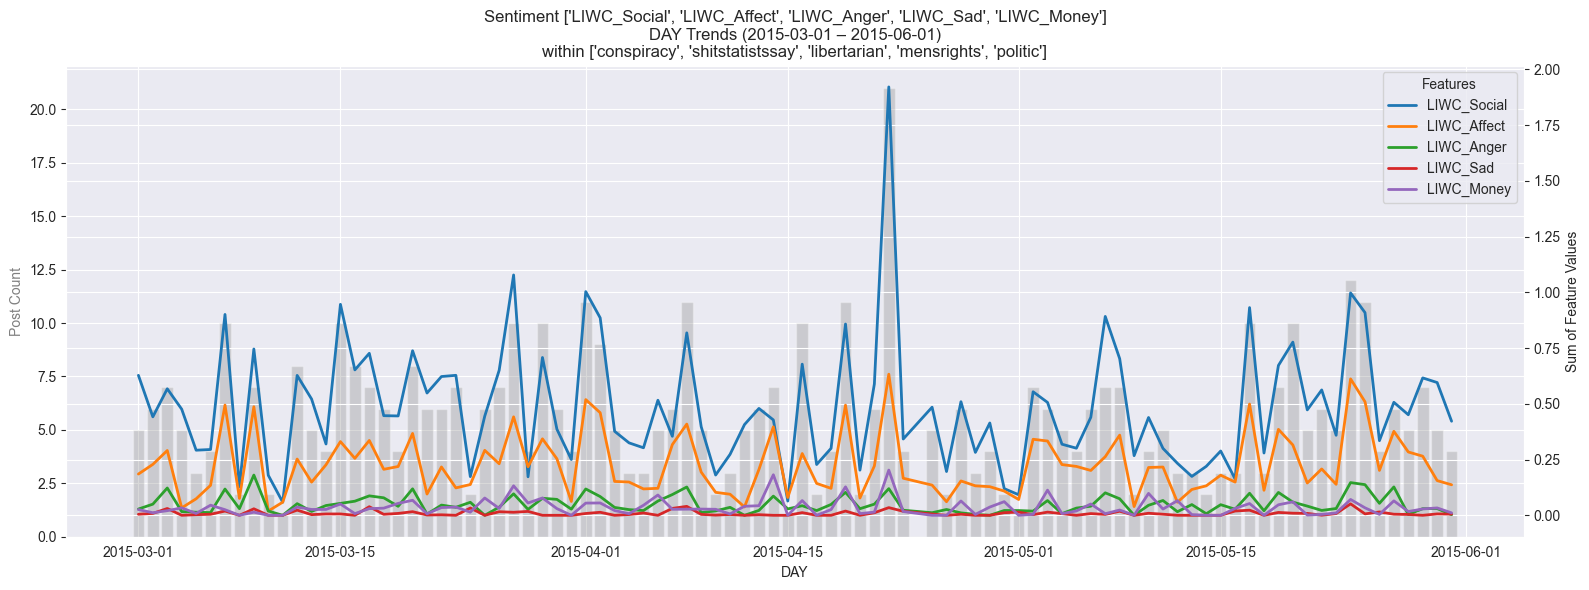

Body


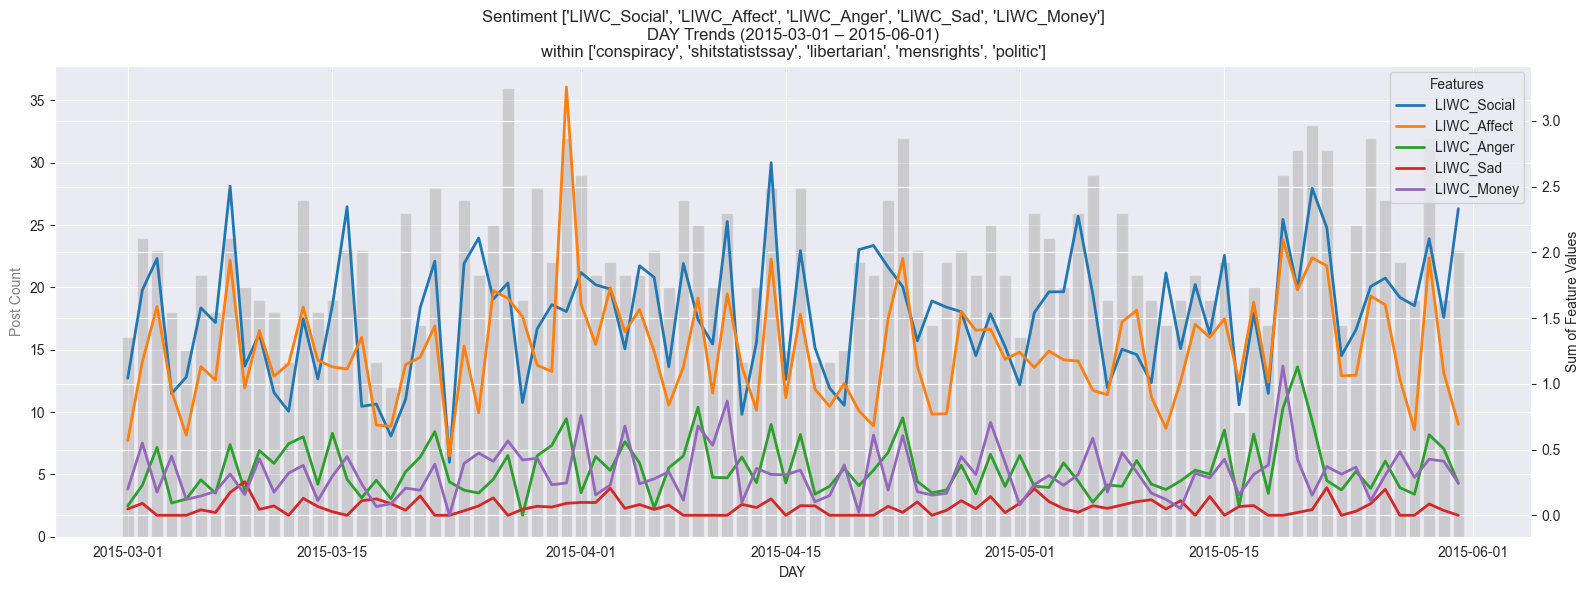

In [15]:
from week1_Yuri import plot_subreddits_features_trend
from week1_Yuri import features

## YURI
df_body_features = df_body["PROPERTIES"].apply(lambda s: [float(x) for x in s.split(",")])
features_body_df = pd.DataFrame(df_body_features.tolist(), columns=features, index=df_body.index)
df_body_prop = pd.concat([df_body.drop(columns=["PROPERTIES"]), features_body_df], axis=1)
## END YURI

## YURI
df_title_features = df_title["PROPERTIES"].apply(lambda s: [float(x) for x in s.split(",")])
features_title_df = pd.DataFrame(df_title_features.tolist(), columns=features, index=df_title.index)
df_title_prop = pd.concat([df_title.drop(columns=["PROPERTIES"]), features_title_df], axis=1)
## END YURI

subreddits_list = df_filtre['SOURCE_SUBREDDIT'].unique().tolist()
start_time = "2015-03-01"
end_time = "2015-06-01"
features_list = [
    "LIWC_Social",
    "LIWC_Affect",
    "LIWC_Anger",
    "LIWC_Sad",
    "LIWC_Money"
]
period = "D"  # "D" for daily, "W" for weekly, "M" for monthly, "Q" for quarterly, "Y" for yearly
print("Title")
plot_subreddits_features_trend(df_body_prop, subreddits_list, start_time, end_time, features_list, period)
print("Body")
plot_subreddits_features_trend(df_title_prop, subreddits_list, start_time, end_time, features_list, period)

- 8-9 november: election poll takes place
- 23 november: Jill Stein contests election results in 3 states and announces a new counting
- 20 september: Russia elections

In [ ]:
WILL PUSH THE REST TOMORROW HERE